In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Customer_Segmentation_py.csv")
df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,12/04/2016,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,02/04/2014,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,02/04/2016,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,04/03/2014,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [6]:
df.shape

(113036, 18)

In [5]:
df.dtypes

Date                  str
Day                 int64
Month                 str
Year                int64
Customer_Age        int64
Age_Group             str
Customer_Gender       str
Country               str
State                 str
Product_Category      str
Sub_Category          str
Product               str
Order_Quantity      int64
Unit_Cost           int64
Unit_Price          int64
Profit              int64
Cost                int64
Revenue             int64
dtype: object

In [6]:
df.isnull().sum()

Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64

In [5]:
df.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [6]:
df.mode(numeric_only=True)

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,24.0,2014,31.0,1.0,2.0,5.0,3.0,1252.0,35.0
1,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN


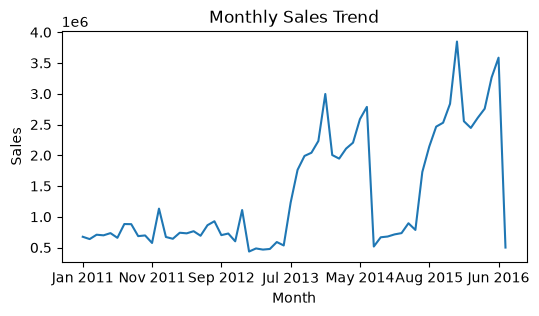

In [8]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Revenue'].sum()
monthly_sales.index = monthly_sales.index.strftime("%b %Y")
monthly_sales.plot(kind="line", figsize=(6,3))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Observation

Monthly sales show significant fluctuations over time. Sales remain relatively low during the earlier periods but increase substantially in later periods, with several noticeable peaks and declines.

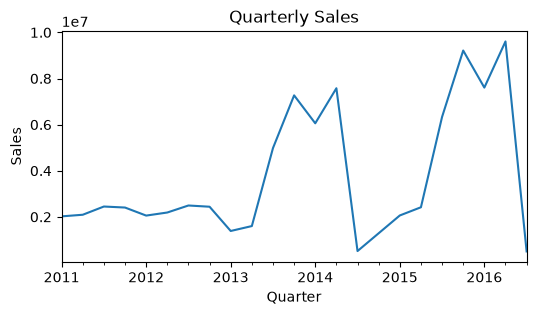

In [15]:
quarterly_sales=df.groupby(df["Date"].dt.to_period("Q"))["Revenue"].sum()
quarterly_sales.plot(kind="line",figsize=(6,3))
plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

### Observation

Quarterly sales also change over time. Sales are higher in the later years. Some quarters have high sales, while others have low sales.

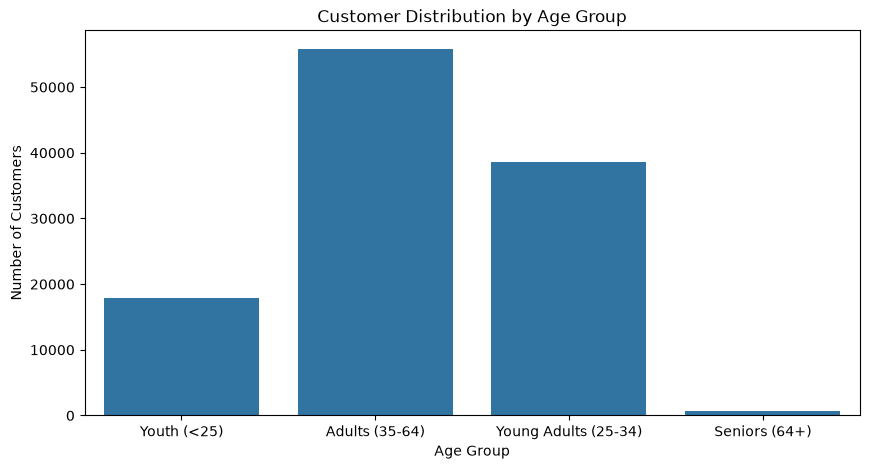

In [10]:
df['Age_Group'].value_counts()
plt.figure(figsize=(10, 5))
sns.countplot(data=df,x="Age_Group")
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

### Observation

Adults aged 35–64 are the largest customer group. Young Adults aged 25–34 are the second largest group. Seniors are the smallest group.

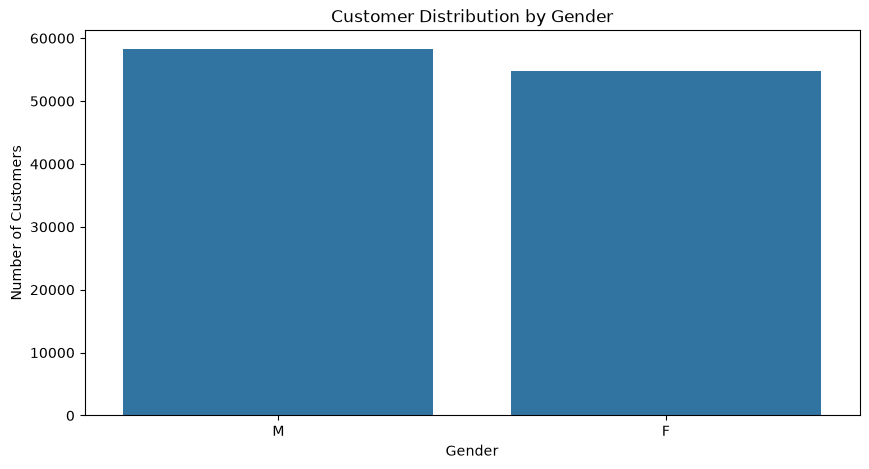

In [12]:
df["Customer_Gender"].value_counts()
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Customer_Gender")
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Observation

The number of male and female customers is very similar. There are slightly more male customers than female customers.

In [5]:
top_10_product=df.groupby("Product")["Order_Quantity"].sum().sort_values(ascending=False).head(10)
top_10_product

Product
Water Bottle - 30 oz.      164086
Patch Kit/8 Patches        157583
Mountain Tire Tube         102792
AWC Logo Cap                67316
Sport-100 Helmet, Red       63663
Road Tire Tube              62296
Fender Set - Mountain       62118
Sport-100 Helmet, Black     62105
Touring Tire Tube           56802
Sport-100 Helmet, Blue      55895
Name: Order_Quantity, dtype: int64

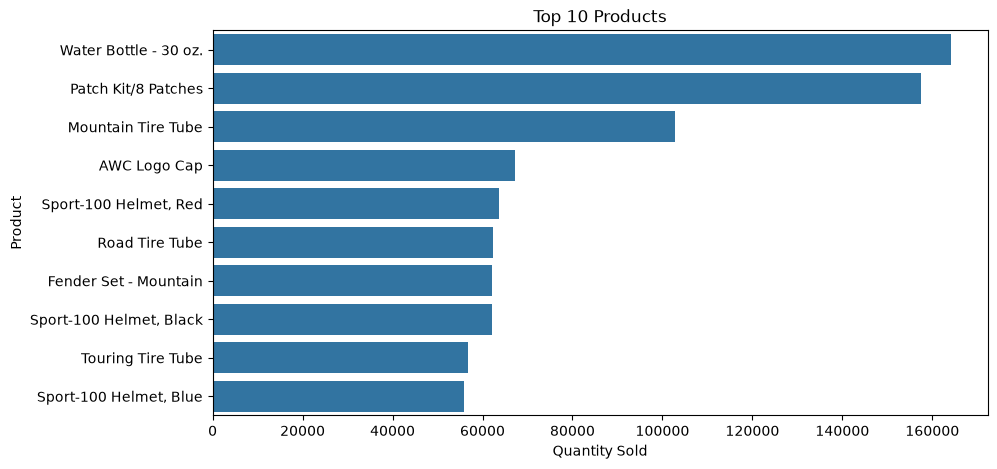

In [6]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_10_product.values,
    y=top_10_product.index
)

plt.title("Top 10 Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

### Observation

Water Bottle - 30 oz. is the best-selling product. Patch Kit/Tube is the second best-selling product. The other products have lower sales.

In [13]:
category_product=df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)
category_product

Product_Category
Bikes          61782134
Accessories    15117992
Clothing        8370882
Name: Revenue, dtype: int64

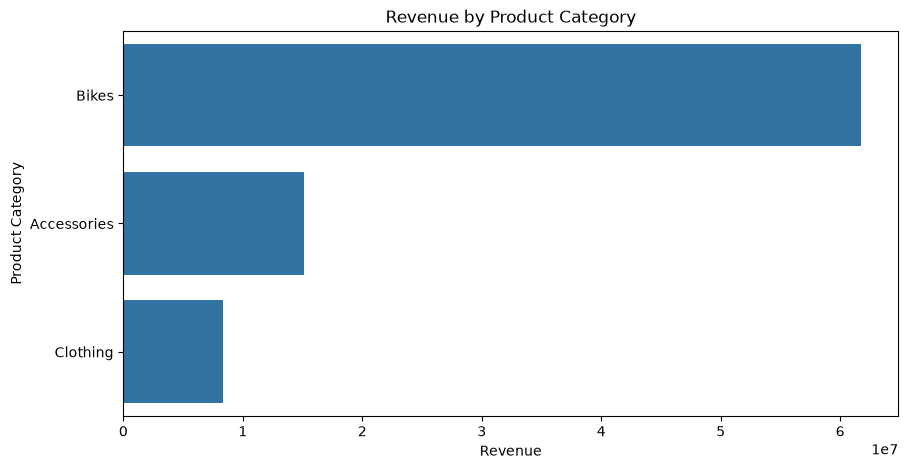

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(
           x=category_product.values,
           y=category_product.index
)
plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.show()

### Observation

Bikes generate the highest revenue. Accessories generate less revenue than Bikes, while Clothing generates the lowest revenue.

In [11]:
numeric_columns = [
    'Customer_Age',
    'Order_Quantity',
    'Unit_Cost',
    'Unit_Price',
    'Profit',
    'Cost',
    'Revenue'
]

In [13]:
correlation_matrix=df[numeric_columns].corr()
correlation_matrix

,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Customer_Age,1.000000,0.026887,-0.021374,-0.020262,0.004319,-0.016013,-0.009326
Order_Quantity,0.026887,1.000000,-0.515835,-0.515925,-0.238863,-0.340382,-0.312895
Unit_Cost,-0.021374,-0.515835,1.000000,0.997894,0.741020,0.829869,0.817865
Unit_Price,-0.020262,-0.515925,0.997894,1.000000,0.749870,0.826301,0.818522
Profit,0.004319,-0.238863,0.741020,0.749870,1.000000,0.902233,0.956572
Cost,-0.016013,-0.340382,0.829869,0.826301,0.902233,1.000000,0.988758
Revenue,-0.009326,-0.312895,0.817865,0.818522,0.956572,0.988758,1.000000


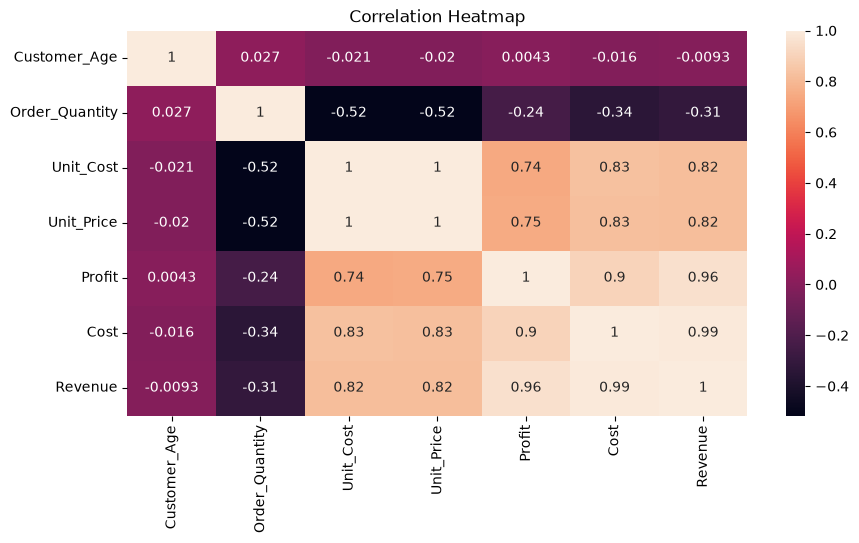

In [15]:
plt.figure(figsize=(10,5))
sns.heatmap(
    correlation_matrix,
    annot=True
)
plt.title('Correlation Heatmap')
plt.show()

### Observation

Revenue has a very strong positive relationship with Profit and Cost. Order Quantity has a negative relationship with Unit Price. This means that higher prices are linked with lower order quantities in this dataset.

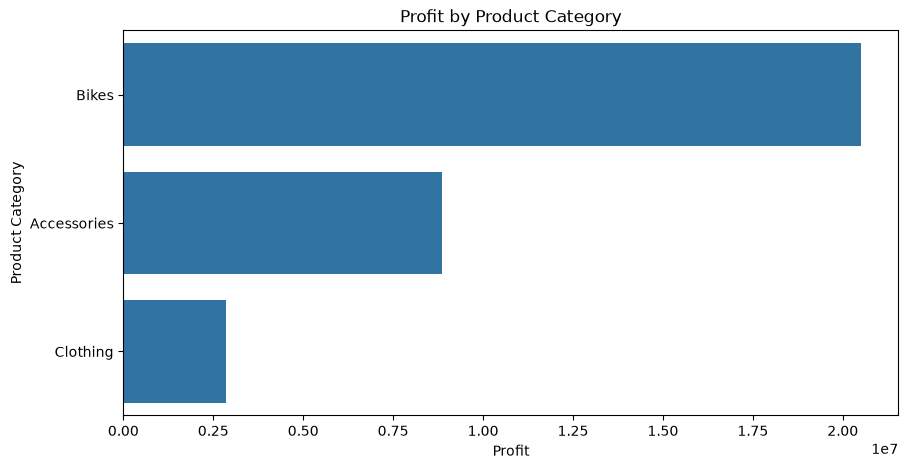

In [17]:
category_profit=df.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_profit.values,
    y=category_profit.index
)
plt.title("Profit by Product Category")
plt.xlabel("Profit")
plt.ylabel("Product Category")
plt.show()

### Observation

Bikes generate the highest profit. Accessories are in second place, while Clothing generates the lowest profit.

# Conclusion

## Key Findings
Adults aged 35–64 are the largest customer group.
Bikes generate the highest revenue and profit.
Water Bottle - 30 oz. is the best-selling product.
Revenue has a strong relationship with Profit and Cost

### Business Recommendations

1. Increase stock of the best-selling products to meet customer demand.

2. Focus marketing activities on Bikes because this category generates the highest revenue and profit.

3. Review the Clothing category to understand why it has lower revenue and profit.